<div style="display:inline-block;vertical-align:top;">
<img src= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ36aRaP-O1Sp0mzIRnmnZrE4yvLUuX6_dIog&s" width=500>

# **Seminario Tendencias de la Inteligencia Artificial en Salud**

# ***Deep Learning***

# **Ejemplo:** Clasificando Radiografías de Tuberculosis (TB)

**Alvaro David Orjuela Cañón, D.Sc.**

Profesor Asociado de Carrera

Escuela de Medicina y Ciencias de la Salud

alvaro.orjuela@urosario.edu.co

# **Importamos herramientas de Tensorflow**

Usamos [Tensorflow](https://www.tensorflow.org/learn?hl=es-419) como *Framework* para la creación, implementación de redes neuronales.
También, es útil con algunas funciones para el preprocesamiento y facilidad de uso con imágenes.

<div style="display:inline-block;vertical-align:top;">
<img src= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTqipz-LRjYVCR1zWPdSH_wXolKX7YIfWPMAA&s" width=500>

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Activation, Dropout, Lambda
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd


# **Cargar Datos**

Vamos a utilizar un dataset asociado a **Tuberculosis (TB) Chest X-ray Database** que se encuentra en [Kaggle - TB Dataset](https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset). Allí se encuentra una base de datos de radiografías asociadas a TB y otras de pacientes normales.

<div style="display:inline-block;vertical-align:top;">
<img src= "https://storage.googleapis.com/kaggle-datasets-images/891819/1513418/504992b51ad9441ba04dfdb40cd40910/dataset-cover.jpg?t=2021-02-16-14-35-19" width=500>

**Descargamos directamente la base de datos desde Kaggle**


* Descargamos la base de datos
* Descomprimimos

In [ ]:
!curl -L -o tuberculosis-tb-chest-xray-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/tawsifurrahman/tuberculosis-tb-chest-xray-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  663M  100  663M    0     0  21.3M      0  0:00:31  0:00:31 --:--:-- 23.7M


In [ ]:
!unzip tuberculosis-tb-chest-xray-dataset.zip -d TB

Archive:  tuberculosis-tb-chest-xray-dataset.zip
  inflating: TB/TB_Chest_Radiography_Database/Normal.metadata.xlsx  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-10.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-100.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1000.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1001.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1002.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1003.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1004.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1005.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1006.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1007.png  
  inflating: TB/TB_Chest_Radiography_Database/Normal/Normal-1008.png  
  inflating: TB/TB_Chest_Radiography

### **Visualización de las Imágenes**

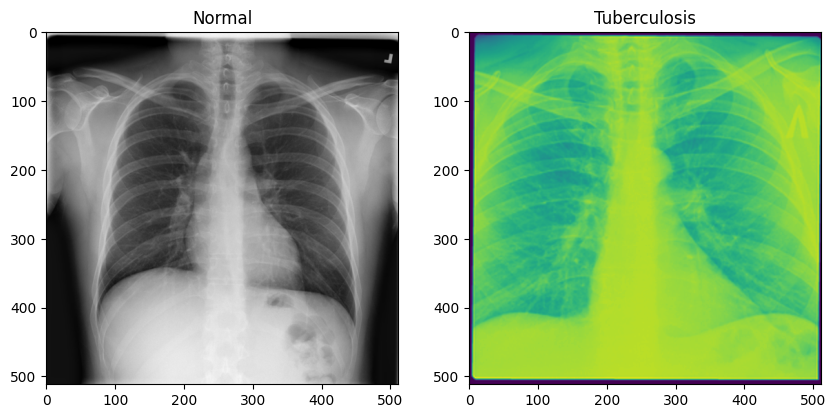

In [ ]:
data_root='/content/TB/TB_Chest_Radiography_Database/'  # Dirección de la carpeta
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1) # Normal
Normal_img = plt.imread(data_root + '/Normal/Normal-10.png')
plt.imshow(Normal_img)
plt.title('Normal')

plt.subplot(1,2,2) # Tuberculosis
Tuberculosis_img = plt.imread(data_root + '/Tuberculosis/Tuberculosis-10.png')
plt.imshow(Tuberculosis_img)
plt.title('Tuberculosis')
plt.show()

### **Normalización de las Imágenes**

**Predefinimos escalamiento, zoom, rotación, entre otros factores de las imágenes**

In [ ]:
# Configuración de los generadores de datos con aumento de datos sobre las imágenes más agresivo
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

### **Creación de Subconjuntos: Train-Test**

**Extraemos las imágenes para nuestros conjuntos:**
* Entrenamiento
* Validación
* Test

In [ ]:
data_root='/content/TB/TB_Chest_Radiography_Database/'  # Dirección de la carpeta
IMAGE_SHAPE = (192, 192)                                # Tamaño de las imágenes
TRAINING_DATA_DIR = str(data_root)
print(TRAINING_DATA_DIR);

datagen_kwargs = dict(rescale=1./255, validation_split=.20)
valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)
valid_generator = valid_datagen.flow_from_directory(
TRAINING_DATA_DIR,
subset="validation",
shuffle=True,
target_size=IMAGE_SHAPE
)
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)

# Función generadora del conjunto de imágenes para entranmiento
train_generator = train_datagen.flow_from_directory(
TRAINING_DATA_DIR,
subset="training",
shuffle=True,
batch_size = 64,                  # Tamaño de lote para entrenar
target_size=IMAGE_SHAPE)

/content/TB/TB_Chest_Radiography_Database/
Found 840 images belonging to 2 classes.
Found 3360 images belonging to 2 classes.


In [ ]:
image_batch_train, label_batch_train = next(iter(train_generator))
print("Image batch shape: ", image_batch_train.shape)
print("Label batch shape: ", label_batch_train.shape)
dataset_labels = sorted(train_generator.class_indices.items(), key=lambda pair:pair[1])
dataset_labels = np.array([key.title() for key, value in dataset_labels])
print(dataset_labels)

Image batch shape:  (64, 192, 192, 3)
Label batch shape:  (64, 2)
['Normal' 'Tuberculosis']


## **Visualización de las Imágenes Normalizadas**

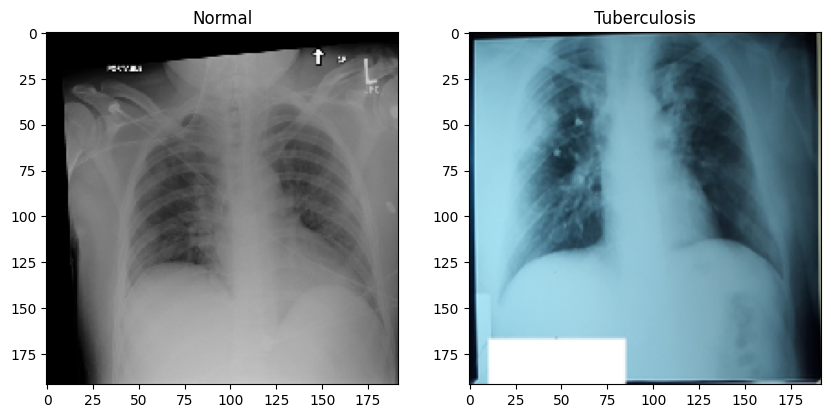

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1) # Normal
plt.imshow(image_batch_train[63])
plt.title('Normal')

plt.subplot(1,2,2) # Tuberculosis
plt.imshow(image_batch_train[0])
plt.title('Tuberculosis')
plt.show()

# **Red Neuronal Convolucional - CNN**

<div style="display:inline-block;vertical-align:top;">
<img src= "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSVd3Tt86JqzsVgeZkXVoyooTt_SolBWxjXzQ&s" width=500>



### **Definiendo la Arquitectura de Nuestra Red Neuronal**


La API de Keras nos permite construir la red neuronal de dos formas:
*   Modelo Secuencial
*   Modelo Funcional

Definiremos una red de **Modelo Secuencial** agregando diferentes capas una por una:

In [ ]:
def cnn_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(192,192,3)))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation='softmax'))
    model.summary()
    return model

In [ ]:
model1 = cnn_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 192, 192, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 190, 190, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 95, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 95, 95, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 93, 93, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 135424)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    69,337,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,404,194 (264.76 MB)

 Trainable params: 69,404,194 (264.76 MB)

 Non-trainable params: 0 (0.00 B)

### **Compilando el modelo**

La red neuronal ahora se ha definido y debe completarse agregando:
* Función de costo (*loss*)
* Optimizador (*optimizer*)
* Métricas de rendimiento (*metrics*)

In [ ]:
model1.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=1.0e-4),
              metrics = ['accuracy'])

### **Entrenamiento del Modelo**

Establecemos unos ***checkpoints*** para guardar los diferentes valores de interés (pesos sinápticos), almancenando el archivo en un formato **.h5*. Esto nos permite tener trazabilidad de los valores de métricas importantes del rendimiento de la red neuronal.

Entrenamos con el método *fit*

In [ ]:
checkpoint = ModelCheckpoint('TB_Chest_Classification.keras',
                             monitor='val_loss',
                             verbose=1,
                             save_best_only= True,
                             mode='auto')

In [ ]:
model_details = model1.fit(train_generator,
                    batch_size = 32,
                    epochs = 20,
                    #validation_data=val_set,
                    #validation_split= 0.1,
                    callbacks=[checkpoint],
                    verbose=1)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.9928 - loss: 0.0293

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


53/53 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9928 - loss: 0.0294  
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9835 - loss: 0.0468 
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 700ms/step - accuracy: 0.9902 - loss: 0.0325
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9899 - loss: 0.0259  
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9925 - loss: 0.0251  
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9928 - loss: 0.0230  
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9965 - loss: 0.0165  
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9925 - loss: 0.0192  
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 715ms/step - accuracy: 0.9931 - loss: 0.0172
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9955 - loss: 0.0136  
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9947 - loss: 0.0152  
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy

### **Evaluando los Resultados**

Tomamos datos de validación y calculamos métricas de desempeño de la red.

Generamos las imágenes de validación

In [ ]:
val_image_batch, val_label_batch = next(iter(valid_generator))
true_label_ids = np.argmax(val_label_batch, axis=-1)
print("Validation batch shape:", val_image_batch.shape)

Validation batch shape: (32, 192, 192, 3)


Calculamos el desempeño sobre el conjunto de **validación** de imágenes aplicado al modelo

In [ ]:
scores = model1.evaluate(val_image_batch, val_label_batch)
print("Accuracy: %.2f%%" % (scores[1]*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9375 - loss: 0.2357
Accuracy: 93.75%


In [ ]:
tf_model_predictions = model1.predict(val_image_batch)
tf_pred_dataframe = pd.DataFrame(tf_model_predictions)
tf_pred_dataframe.columns = dataset_labels
print("Prediction results for the first elements")
tf_pred_dataframe

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction results for the first elements


,Normal,Tuberculosis
0,1.000000e+00,3.497672e-16
1,1.000000e+00,9.803931e-15
2,1.000000e+00,4.752630e-20
3,1.000000e+00,8.945660e-25
4,1.000000e+00,4.518953e-14
5,1.000000e+00,2.572001e-13
6,1.000000e+00,7.929284e-18
7,1.000000e+00,2.703945e-17
8,1.000000e+00,1.494459e-11
9,9.032055e-13,1.000000e+00


### **Matriz de Confusión del Conjunto de Validación**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_hat_te1 = model1.predict(val_image_batch,verbose=1)
y_hat_te1 = np.argmax(y_hat_te1,axis=1)
print(classification_report(true_label_ids, y_hat_te1)) #, target_names = names))
print(confusion_matrix(true_label_ids, y_hat_te1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        27
           1       1.00      0.60      0.75         5

    accuracy                           0.94        32
   macro avg       0.97      0.80      0.86        32
weighted avg       0.94      0.94      0.93        32

[[27  0]
 [ 2  3]]


**Análisis de los Resultados**

Evaluamos la gráfica del entrenamiento

<div style="display:inline-block;vertical-align:top;">
<img src= "https://miro.medium.com/max/944/1*0lDcZ7E872CDwrWCYkj9EQ.jpeg" width=300> <img src= "https://cs231n.github.io/assets/nn3/learningrates.jpeg" width=300>

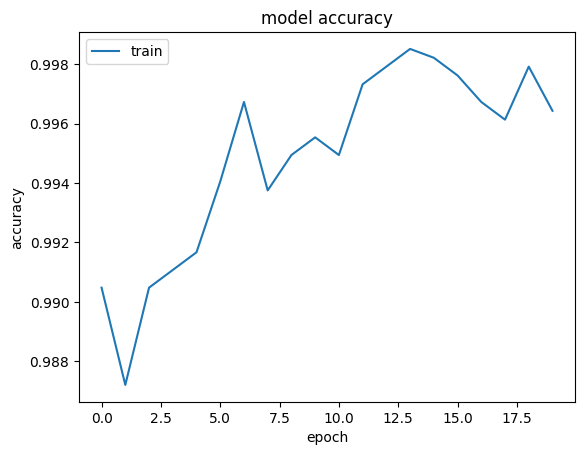

In [ ]:
plt.plot(model_details.history['accuracy'])
#plt.plot(model_details.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

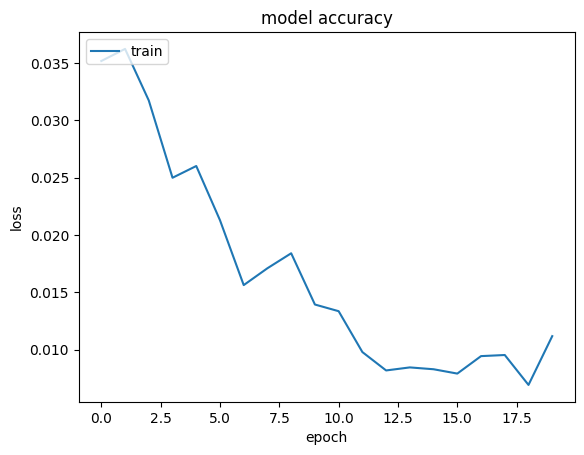

In [ ]:
plt.plot(model_details.history['loss'])
#plt.plot(model_details.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# **Transfer Learning**

Vamos a usar una red ***MobileNet***



## **Cargando *[MobileNet](https://arxiv.org/abs/1704.04861)***

In [ ]:
from keras.applications.mobilenet import MobileNet
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten, BatchNormalization
from keras.models import Sequential, Model
# ---- Cambiar el 'input_shape' de acuerdo al problema
base_model = MobileNet(weights='imagenet',include_top=False,input_shape=(192,192,3)) #Importa la red sin la última capa de 1000 neuronas

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## **Modificamos la red para nuestro problema**

Para esto, proponemos el uso del método **funcional** para definir la arquitectura

In [ ]:
x=base_model.output
x=GlobalAveragePooling2D()(x)

x=Dense(1024,activation='relu')(x) # Agregamos capa dense 1
x=Dense(1024,activation='relu')(x) # Agregamos capa dense 2
x=Dense(512,activation='relu')(x) # Agregamos capa dense 3

preds=Dense(2,activation='softmax')(x) # Capa de salida (Clase vs. No Clase)

**Congelamos pesos sinápticos para entrenar solo las últimas 4 capas**

In [ ]:
model2 = Model(inputs=base_model.input,outputs=preds)
for layer in model2.layers[:20]:
    layer.trainable=False
for layer in model2.layers[20:]:
    layer.trainable=True

In [ ]:
model2.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1.0e-4), metrics = ['accuracy'])
model2.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 96, 96, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 96, 96, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 96, 96, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 96, 96, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 97, 97, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 48, 48, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 48, 48, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 48, 48, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 48, 48, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 5,853,890 (22.33 MB)

 Trainable params: 5,817,986 (22.19 MB)

 Non-trainable params: 35,904 (140.25 KB)

## **Entrenamiento de la *MobileNet* adaptada**

In [ ]:
model_details = model2.fit(train_generator,
                    batch_size = 32,
                    epochs = 10,
                    #validation_data=val_set,
                    #validation_split= 0.1,
                    callbacks=[checkpoint],
                    verbose=1)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.8991 - loss: 0.2171

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


53/53 ━━━━━━━━━━━━━━━━━━━━ 77s 870ms/step - accuracy: 0.9003 - loss: 0.2148
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 535ms/step - accuracy: 1.0000 - loss: 7.8126e-04
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 542ms/step - accuracy: 0.9991 - loss: 0.0030
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 540ms/step - accuracy: 1.0000 - loss: 5.6035e-04
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 538ms/step - accuracy: 1.0000 - loss: 2.1085e-04
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 552ms/step - accuracy: 1.0000 - loss: 6.2601e-05
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 551ms/step - accuracy: 1.0000 - loss: 3.4601e-05
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 550ms/step - accuracy: 1.0000 - loss: 2.8050e-05
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 559ms/step - accuracy: 1.0000 - loss: 3.7538e-05
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 552ms/step - accuracy: 1.0000 - loss: 2.3947e-05


## **Validación con otro subconjunto de datos**

Tomamos datos de validación y calculamos métricas de desempeño de la red.

Generamos las imágenes de validación

In [ ]:
val_image_batch, val_label_batch = next(iter(valid_generator))
true_label_ids = np.argmax(val_label_batch, axis=-1)
print("Validation batch shape:", val_image_batch.shape)

Validation batch shape: (32, 192, 192, 3)


Calculamos el desempeño sobre el conjunto de **validación** de imágenes aplicado al modelo

In [ ]:
scores = model2.evaluate(val_image_batch, val_label_batch)
print("Accuracy: %.2f%%" % (scores[1]*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 5.7644e-04
Accuracy: 100.00%


In [ ]:
tf_model_predictions = model2.predict(val_image_batch)
tf_pred_dataframe = pd.DataFrame(tf_model_predictions)
tf_pred_dataframe.columns = dataset_labels
print("Prediction results for the first elements")
tf_pred_dataframe

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction results for the first elements


,Normal,Tuberculosis
0,1.000000e+00,5.360136e-15
1,1.000000e+00,1.157582e-19
2,1.000000e+00,1.330718e-12
3,1.000000e+00,4.983460e-16
4,1.000000e+00,7.266920e-17
5,1.000000e+00,1.987595e-12
6,6.333253e-11,1.000000e+00
7,1.000000e+00,7.222541e-12
8,1.000000e+00,5.343369e-10
9,1.000000e+00,2.532865e-16


**Matriz de Confusión del Conjunto de Validación**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_hat_te2 = model2.predict(val_image_batch,verbose=1)
y_hat_te2 = np.argmax(y_hat_te2,axis=1)
print(classification_report(true_label_ids, y_hat_te2)) #, target_names = names))
print(confusion_matrix(true_label_ids, y_hat_te2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00         4

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32

[[28  0]
 [ 0  4]]


**Figuras del Entrenamiento**

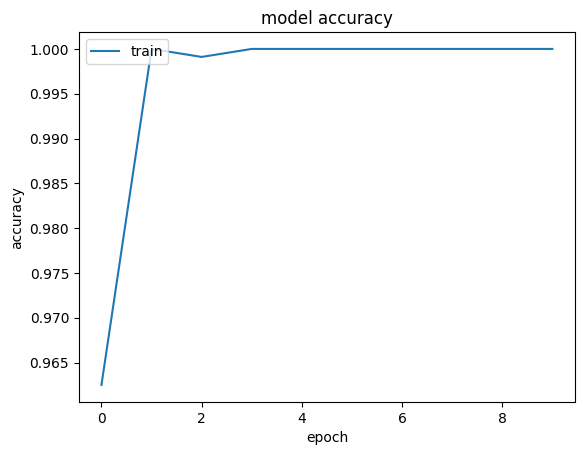

In [ ]:
plt.plot(model_details.history['accuracy'])
#plt.plot(model_details.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

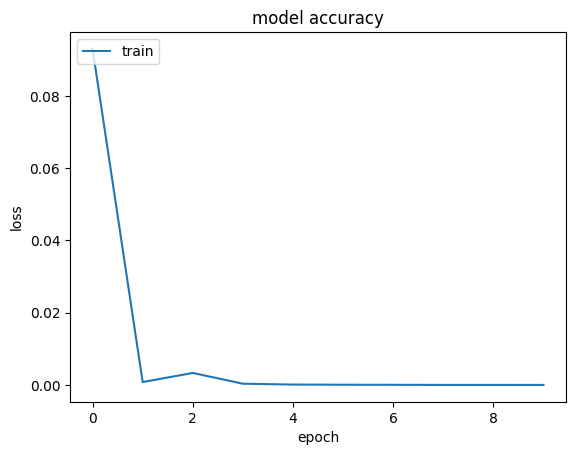

In [ ]:
plt.plot(model_details.history['loss'])
#plt.plot(model_details.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()